# Would instructional faculty recommend their department? Using XAI and Causality

## Henry Salgado
### Date: May 15, 2025

Let's look at two samples, 1) NTT Instructional Faculty and 2) Tenured Faculty. We will start with 1. 

In [ ]:
import pandas as pd
import numpy as np
import scipy 

non_response_codes = [96, 97, 98, 99]

#data = pd.read_excel('/Users/henrysalgado/Desktop/Coache Data Analysis/Samples/sample1_hsi_stem_instructional.xlsx')
data = pd.read_excel('/Users/henrysalgado/Desktop/Coache Data Analysis/Samples/del_sample1_hsi_stem_instructional copy.xlsx')
data.replace(non_response_codes, np.nan, inplace=True)
data.describe()


,q2,q3,q4,q5,q20,q21,q10,q11,q12,q13,...,q270b_18,q270b_19,q270b_20,q270b_21,q270b_22,q270b_23,q270b_24,q270b_25,q270b_98,q305
count,970.0,0.0,0.0,970.000000,970.000000,36.000000,466.000000,6.000000,919.000000,131.0,...,971.0,971.0,971.0,971.0,971.0,971.0,971.0,971.0,971.0,467.000000
mean,1.0,NaN,NaN,2.176289,1.782474,1.500000,2.809013,3.166667,1.696409,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.438972
std,0.0,NaN,NaN,1.065867,0.881587,0.845154,0.974958,0.983192,1.498110,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.496794
min,1.0,NaN,NaN,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,1.0,NaN,NaN,2.000000,1.000000,1.000000,2.000000,2.250000,1.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,1.0,NaN,NaN,2.000000,1.000000,1.000000,3.000000,3.500000,1.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,1.0,NaN,NaN,2.000000,3.000000,2.000000,4.000000,4.000000,1.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
max,1.0,NaN,NaN,9.000000,3.000000,3.000000,4.000000,4.000000,6.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Majority of faculty would recommend their department (2), some with resevation (1) and 61 faculty would not recommend.

In [86]:
data['q265'].value_counts()

2.0    444
1.0    298
0.0     61
Name: q265, dtype: int64

Selected features: ['q45a', 'q45b', 'q45c', 'q45e', 'q55a', 'q55b', 'q60a', 'q60b', 'q60c', 'q60d', 'q60e', 'q70a', 'q70b', 'q70c', 'q70d', 'q70e', 'q70f', 'q70h', 'q80a', 'q80b', 'q80d', 'q85a', 'q85d', 'q90a', 'q90c', 'q90d', 'q90e', 'q90f', 'q90g', 'q90h', 'q95a', 'q105a', 'q105e', 'q105d', 'q120a', 'q120b', 'q120c', 'q130a', 'q190a', 'q190c', 'q190d', 'q190e', 'q195a', 'q200a', 'q205c', 'q205d', 'q210a', 'q210c']
Classification Report:

              precision    recall  f1-score   support

         0.0       0.59      0.61      0.60       124
         1.0       0.63      0.65      0.64       584
         2.0       0.76      0.74      0.75       678

    accuracy                           0.69      1386
   macro avg       0.66      0.67      0.66      1386
weighted avg       0.69      0.69      0.69      1386


Cross-validated F1 Macro: 0.664 ± 0.014
Best Accuracy: 0.70 with 17 features.


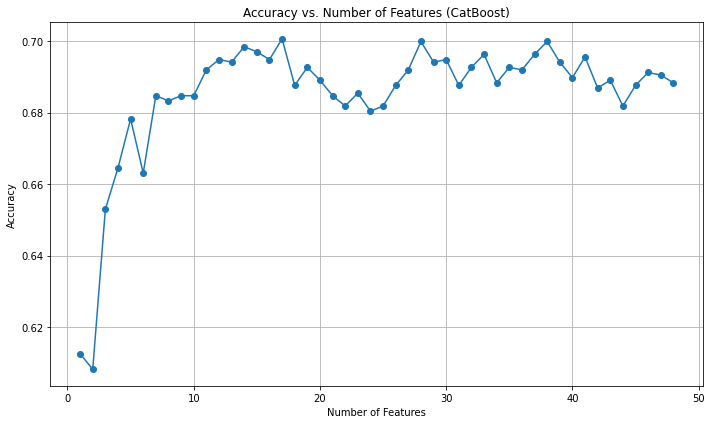

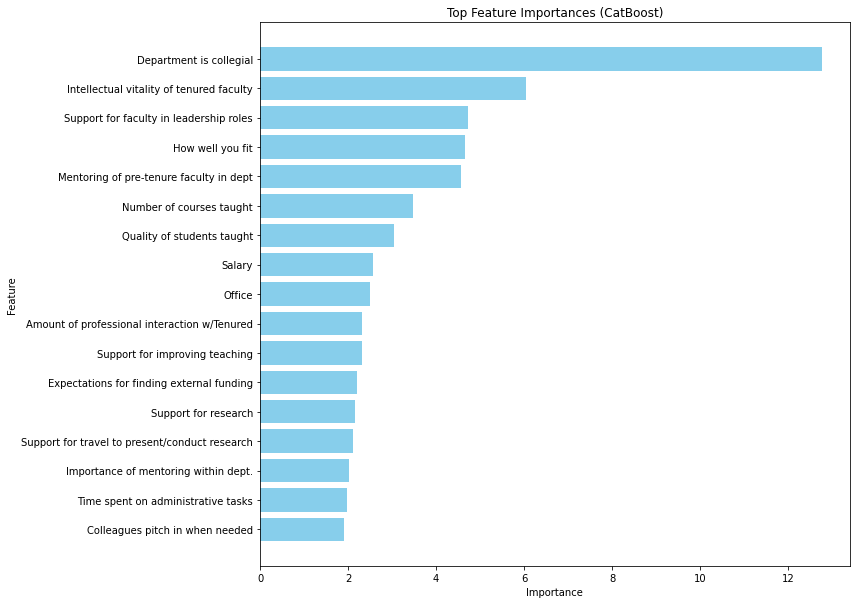

Top 17 Features:
Feature                            Feature_Description
  q210c                        Department is collegial
  q195a       Intellectual vitality of tenured faculty
   q55b        Support for faculty in leadership roles
  q205c                               How well you fit
  q130a        Mentoring of pre-tenure faculty in dept
   q70a                       Number of courses taught
   q70e                     Quality of students taught
   q90g                                         Salary
   q90a                                         Office
  q205d   Amount of professional interaction w/Tenured
   q70f                 Support for improving teaching
   q80a      Expectations for finding external funding
   q80d                           Support for research
   q85d Support for travel to present/conduct research
  q120a           Importance of mentoring within dept.
   q45e             Time spent on administrative tasks
  q210a                Colleagues pitch in when 

In [102]:
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.experimental import enable_iterative_imputer  

variables = [
    "q45a", "q45b", "q45c", "q45d", "q45e", "q45f",
    "q50a", "q50b", "q50c", "q50d", "q50e", "q50f",
    "q55a", "q55b", "q60a", "q60b", "q60c", "q60d",
    "q60f", "q60g", "q60e", "q60h", "q60i", "q70a",
    "q70b", "q70c", "q70d", "q70e", "q70i", "q70f",
    "q70h", "q70j", "q70k", "q70l", "q70m", "q70n",
    "q80a", "q80b", "q80c", "q80d", "q80e", "q85a",
    "q85b", "q85c", "q85d", "q85e", "q90a", "q90b",
    "q90c", "q90d", "q90e", "q90f", "q90g", "q90h",
    "q92a", "q92b", "q92c", "q92d", "q92e", "q92f",
    "q92g", "q92h", "q92i", "q92j", "q95a", "q95b",
    "q95c", "q95d", "q95e", "q95f", "q95g", "q95h",
    "q95i", "q95j", "q95k", "q95l", "q95m", "q95n",
    "q99", "q98a", "q98b", "q98c", "q100a", "q100b",
    "q100c", "q100d", "q100e", "q100f", "q100g", "q105a",
    "q105e", "q105d", "q115", "q120a", "q120b", "q120c",
    "q125a", "q125b", "q125c", "q130a", "q130b", "q130d",
    "q130c", "q135b", "q135c", "q135d", "q135e", "q136a",
    "q136b", "q136c", "q136d", "q136f", "q136e", "q132",
    "q133ns", "q137a", "q137b", "q137c", "q137d", "q137e",
    "q137f", "q137g", "q138a", "q138b", "q138c", "q138d",
    "q138e", "q138f", "q139a", "q139b", "q140a", "q140b",
    "q140c", "q140d", "q140e", "q140f", "q145a", "q145b",
    "q150", "q156a", "q156b", "q156c", "q156d", "q156e",
    "q156f", "q450a", "q450b", "q450c", "q450d", "q450e",
    "q460a", "q460b", "q460c", "q460d", "q460e", "q170a",
    "q170c", "q171", "q175a", "q175b", "q175c", "q180a",
    "q180b", "q180c", "q180l", "q180m", "q180n", "q180o",
    "q185d", "q185e", "q185f", "q185g", "q185h", "q185i",
    "q185j", "q185k", "q185l", "q187a", "q186a", "q186b",
    "q186c", "q186d", "q187b", "q188a", "q188b", "q188c",
    "q188d", "q188e", "q189a_a", "q189a_b", "q189a_c", "q189a_d",
    "q189a_e", "q189a_f", "q189b_a", "q189b_b", "q189b_c", "q189b_d",
    "q189b_e", "q189b_f", "q189b_g", "q190a", "q190b", "q190c",
    "q190d", "q190e", "q190f", "q190g", "q195a", "q195b",
    "q195e", "q195c", "q195d", "q195f", "q195g", "q195h",
    "q195i", "q200a", "q200b", "q200c", "q200d", "q205a",
    "q205b", "q205c", "q205d", "q205e", "q205f", "q205g",
    "q206a", "q206b", "q210a", "q210c", "q212a", "q212b",
    "q215a", "q215b", "q215c", "q215d", "q215e", "q215m",
    "q215j", "q215k", "q215l", "q215i", "q220a", "q220b", 
]



X = data[variables]
y = data['q265']

# Step 1: Replace nonresponse codes with NaN
nonresponse_codes = [96, 97, 98, 99]
X = X.replace(nonresponse_codes, np.nan)
y = y.replace(nonresponse_codes, np.nan)

# Step 2: Removing bias
tolerance = 10
missing_percent = X.isnull().mean() * 100
selected_features = missing_percent[missing_percent < tolerance].index.tolist()
X_filtered = X[selected_features]
print(f"Selected features: {selected_features}")

# Step 3: Impute missing values
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X_filtered)
#imputer = IterativeImputer(random_state=42, max_iter=10, sample_posterior=True)
#X_imputed = imputer.fit_transform(X_filtered)
X_imputed_df = pd.DataFrame(X_imputed, columns=selected_features)

# Remove rows where y is NaN
valid_indices = ~y.isnull()
X_final = X_imputed_df[valid_indices]
y_final = y[valid_indices]

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.40,stratify=y_final, random_state=42
)

# Step 5: Train CatBoost and extract importances
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced', iterations=500,
    learning_rate=0.05, depth=4, random_seed=42, verbose=False
)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(cat_model, X_final, y_final, cv=5, scoring='f1_macro')
print(f"\nCross-validated F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


feature_importances = cat_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)


features_sorted = importance_df["Feature"].tolist()
accuracy_scores = []
best_accuracy = 0
best_feature_count = 0

for i in range(1, len(features_sorted) + 1):
    current_features = features_sorted[:i]

    X_train_sel = X_train[current_features]
    X_test_sel = X_test[current_features]

    cat_model.fit(X_train_sel, y_train)
    y_pred = cat_model.predict(X_test_sel)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature_count = i

print(f"Best Accuracy: {best_accuracy:.2f} with {best_feature_count} features.")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(features_sorted) + 1), accuracy_scores, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Features (CatBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()


mapping_df = pd.read_excel("Variables.xlsx")
mapping_df['key'] = mapping_df['key'].str.lower()
name_dict = dict(zip(mapping_df['key'], mapping_df['name']))

importance_df["Feature_Description"] = [
    name_dict.get(feat.lower(), feat) for feat in importance_df["Feature"]
]


plt.figure(figsize=(12, best_feature_count / 2))
top_features_df = importance_df.head(best_feature_count)
plt.barh(top_features_df["Feature_Description"], top_features_df["Importance"], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Top {best_feature_count} Features:")
print(top_features_df[["Feature", "Feature_Description"]].to_string(index=False))





Plotting SHAP beeswarm for class: 0.0


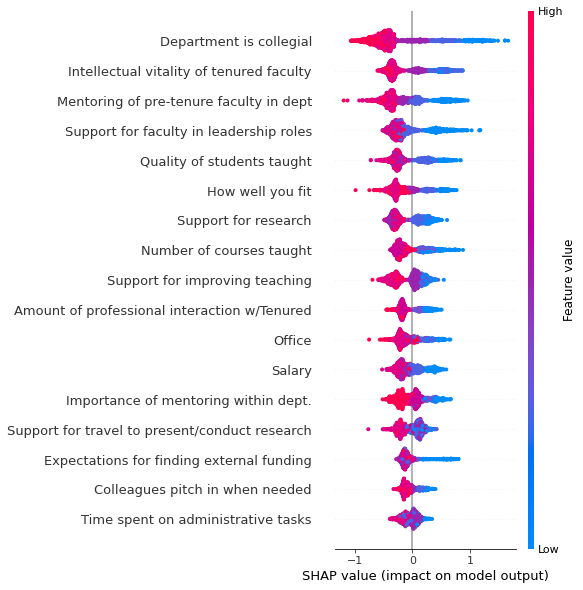

Plotting SHAP beeswarm for class: 1.0


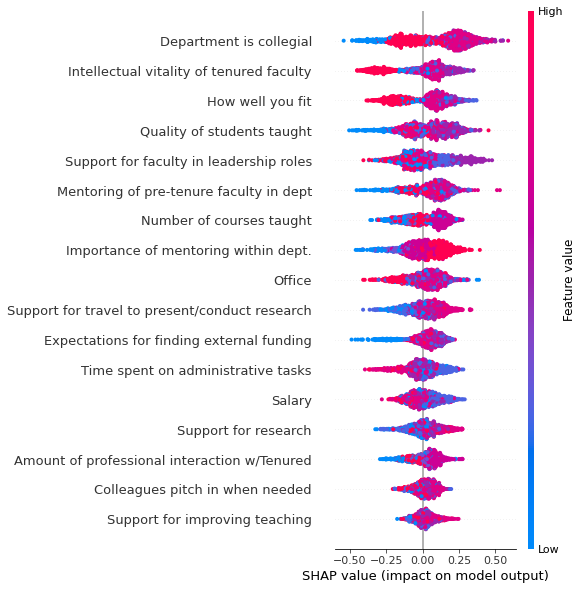

Plotting SHAP beeswarm for class: 2.0


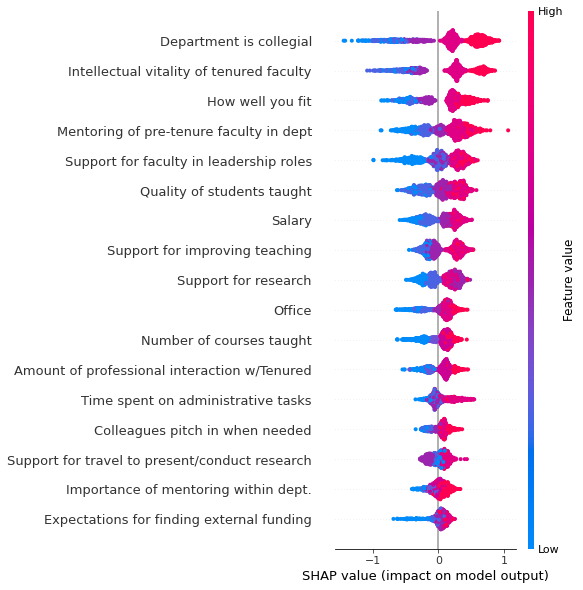

In [103]:
import shap
import matplotlib.pyplot as plt


top_features = features_sorted[:best_feature_count]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

shap_model = CatBoostClassifier(
    auto_class_weights='Balanced', iterations=400,
    learning_rate=0.1, depth=8, random_seed=42, verbose=False
)
shap_model.fit(X_train_top, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_top)

top_feature_descriptions = [name_dict.get(f.lower(), f) for f in top_features]

class_labels = shap_model.classes_

for i, class_name in enumerate(shap_model.classes_):
    print(f"Plotting SHAP beeswarm for class: {class_name}")
    shap.summary_plot(
        shap_values[i],
        features=X_test_top,
        feature_names=top_feature_descriptions,
        plot_type="dot",  # beeswarm
        show=True
    )

_______PC_______


Depth=10, working on node 16: 100%|██████████| 17/17 [00:00<00:00, 88.57it/s]


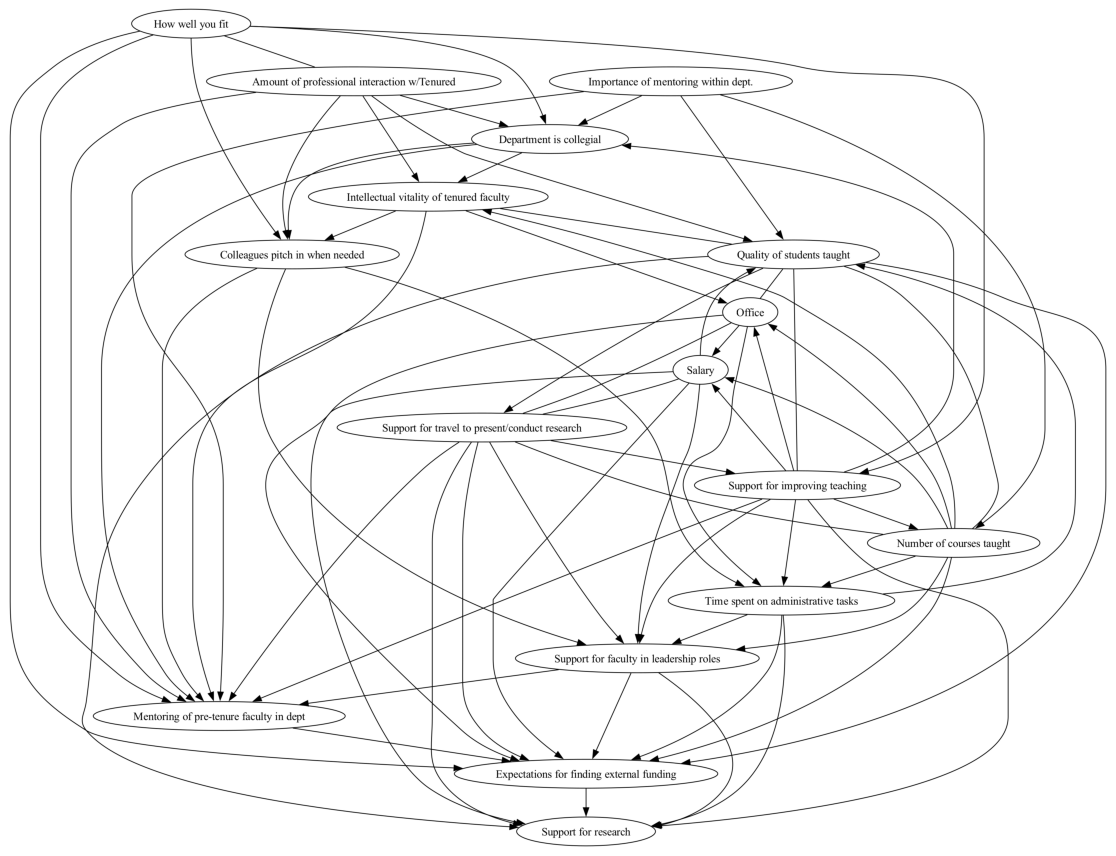

In [104]:
X_for_Causal = X_imputed_df[top_features]


from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
import matplotlib.pyplot as plt
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display
import pandas as pd


X_np = X_for_Causal.to_numpy()  


mapping_df = pd.read_excel("Variables.xlsx")
mapping_df['key'] = mapping_df['key'].str.lower()
name_dict = dict(zip(mapping_df['key'], mapping_df['name']))


original_colnames = [col.lower() for col in X_for_Causal.columns]
node_labels = [name_dict.get(col, col) for col in original_colnames]


print("_______PC_______")
cg_pc = pc(X_np, alpha=0.05, ci_test=fisherz, node_names=node_labels)
cg_pc.draw_pydot_graph()


#print("_______FCI_______")
#cg_fci, sep_set = fci(X_np, alpha=0.05, ci_test="chisq", node_names=node_labels)

# Save FCI graph as PNG
#pdy = GraphUtils.to_pydot(cg_fci)
#pdy.write_png("fci_graph.png")


# 2nd Model with Tenured Faculty

In [105]:
import pandas as pd
import numpy as np
import scipy 


non_response_codes = [96, 97, 98, 99]


data = pd.read_excel('/Users/henrysalgado/Desktop/Coache Data Analysis/Samples/sample4_tenure.xlsx')
data.replace(non_response_codes, np.nan, inplace=True)
data.describe()


,demo_inst_id,hacu_hsi,demo_tenure,demo_rank,demo_race,demo_gender,demo_is_clinical,demo_is_parent_any,demo_is_parent_itp,demo_is_parent_k12,...,q270b_18,q270b_19,q270b_20,q270b_21,q270b_22,q270b_23,q270b_24,q270b_25,q270b_98,q305
count,4021.000000,4021.0,4021.000000,4021.000000,4019.000000,4021.000000,3273.0,4021.000000,4021.000000,4021.000000,...,4021.0,4021.0,4021.0,4021.0,4021.0,4021.0,4021.0,4021.0,4021.0,1606.000000
mean,240.883114,1.0,2.742104,3.132803,3.326449,1.930863,0.0,0.515046,0.159662,0.312609,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.435866
std,88.933391,0.0,0.437531,0.883385,10.302803,4.471101,0.0,0.499836,0.366338,0.463614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.496024
min,126.000000,1.0,2.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,135.000000,1.0,2.000000,2.000000,2.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,243.000000,1.0,3.000000,3.000000,2.000000,2.000000,0.0,1.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,319.000000,1.0,3.000000,4.000000,2.000000,2.000000,0.0,1.000000,0.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
max,404.000000,1.0,3.000000,5.000000,91.000000,91.000000,0.0,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


In [106]:
data['q265'].value_counts()

2.0    1694
1.0    1460
0.0     310
Name: q265, dtype: int64

Selected features: ['q45a', 'q45b', 'q45c', 'q45e', 'q55a', 'q55b', 'q60a', 'q60b', 'q60c', 'q60d', 'q60e', 'q70a', 'q70b', 'q70c', 'q70d', 'q70e', 'q70f', 'q70h', 'q80a', 'q80b', 'q80d', 'q85a', 'q85d', 'q90a', 'q90c', 'q90d', 'q90e', 'q90f', 'q90g', 'q90h', 'q95a', 'q105a', 'q105e', 'q105d', 'q120a', 'q120b', 'q120c', 'q130a', 'q190a', 'q190c', 'q190d', 'q190e', 'q195a', 'q200a', 'q205c', 'q205d', 'q210a', 'q210c', 'q315']
Classification Report:

              precision    recall  f1-score   support

         0.0       0.54      0.66      0.59        93
         1.0       0.65      0.64      0.65       438
         2.0       0.78      0.76      0.77       509

    accuracy                           0.70      1040
   macro avg       0.66      0.69      0.67      1040
weighted avg       0.71      0.70      0.70      1040

Best Accuracy: 0.71 with 11 features.


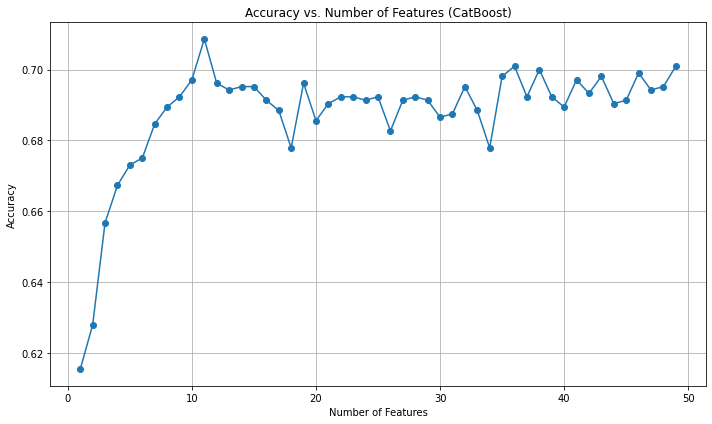

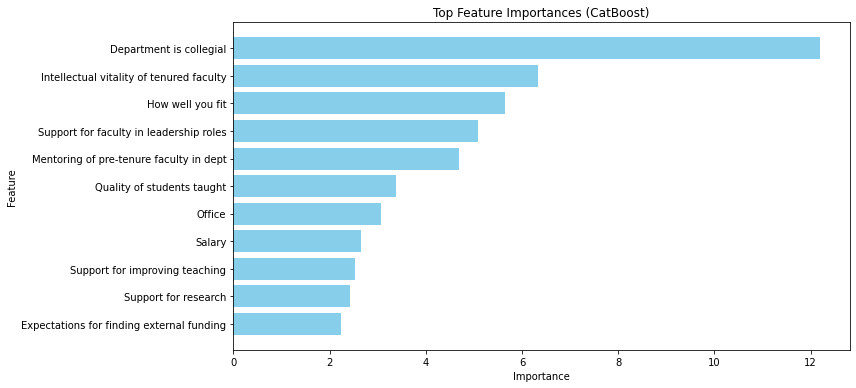

Top 11 Features:
Feature                       Feature_Description
  q210c                   Department is collegial
  q195a  Intellectual vitality of tenured faculty
  q205c                          How well you fit
   q55b   Support for faculty in leadership roles
  q130a   Mentoring of pre-tenure faculty in dept
   q70e                Quality of students taught
   q90a                                    Office
   q90g                                    Salary
   q70f            Support for improving teaching
   q80d                      Support for research
   q80a Expectations for finding external funding


In [107]:
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.metrics import classification_report

variables = [
    "q45a", "q45b", "q45c", "q45d", "q45e", "q45f",
    "q50a", "q50b", "q50c", "q50d", "q50e", "q50f",
    "q55a", "q55b", "q60a", "q60b", "q60c", "q60d",
    "q60f", "q60g", "q60e", "q60h", "q60i", "q70a",
    "q70b", "q70c", "q70d", "q70e", "q70i", "q70f",
    "q70h", "q70j", "q70k", "q70l", "q70m", "q70n",
    "q80a", "q80b", "q80c", "q80d", "q80e", "q85a",
    "q85b", "q85c", "q85d", "q85e", "q90a", "q90b",
    "q90c", "q90d", "q90e", "q90f", "q90g", "q90h",
    "q92a", "q92b", "q92c", "q92d", "q92e", "q92f",
    "q92g", "q92h", "q92i", "q92j", "q95a", "q95b",
    "q95c", "q95d", "q95e", "q95f", "q95g", "q95h",
    "q95i", "q95j", "q95k", "q95l", "q95m", "q95n",
    "q99", "q98a", "q98b", "q98c", "q100a", "q100b",
    "q100c", "q100d", "q100e", "q100f", "q100g", "q105a",
    "q105e", "q105d", "q115", "q120a", "q120b", "q120c",
    "q125a", "q125b", "q125c", "q130a", "q130b", "q130d",
    "q130c", "q135b", "q135c", "q135d", "q135e", "q136a",
    "q136b", "q136c", "q136d", "q136f", "q136e", "q132",
    "q133ns", "q137a", "q137b", "q137c", "q137d", "q137e",
    "q137f", "q137g", "q138a", "q138b", "q138c", "q138d",
    "q138e", "q138f", "q139a", "q139b", "q140a", "q140b",
    "q140c", "q140d", "q140e", "q140f", "q145a", "q145b",
    "q150", "q156a", "q156b", "q156c", "q156d", "q156e",
    "q156f", "q450a", "q450b", "q450c", "q450d", "q450e",
    "q460a", "q460b", "q460c", "q460d", "q460e", "q170a",
    "q170c", "q171", "q175a", "q175b", "q175c", "q180a",
    "q180b", "q180c", "q180l", "q180m", "q180n", "q180o",
    "q185d", "q185e", "q185f", "q185g", "q185h", "q185i",
    "q185j", "q185k", "q185l", "q187a", "q186a", "q186b",
    "q186c", "q186d", "q187b", "q188a", "q188b", "q188c",
    "q188d", "q188e", "q189a_a", "q189a_b", "q189a_c", "q189a_d",
    "q189a_e", "q189a_f", "q189b_a", "q189b_b", "q189b_c", "q189b_d",
    "q189b_e", "q189b_f", "q189b_g", "q190a", "q190b", "q190c",
    "q190d", "q190e", "q190f", "q190g", "q195a", "q195b",
    "q195e", "q195c", "q195d", "q195f", "q195g", "q195h",
    "q195i", "q200a", "q200b", "q200c", "q200d", "q205a",
    "q205b", "q205c", "q205d", "q205e", "q205f", "q205g",
    "q206a", "q206b", "q210a", "q210c", "q212a", "q212b",
    "q215a", "q215b", "q215c", "q215d", "q215e", "q215m",
    "q215j", "q215k", "q215l", "q215i", "q220a", "q220b", "q315"
]


X = data[variables]
y = data['q265']

# Step 1: Dealing w missing data, replacing nonresponse codes with NaN
nonresponse_codes = [96, 97, 98, 99]
X = X.replace(nonresponse_codes, np.nan)
y = y.replace(nonresponse_codes, np.nan)

# Step 2: Minimizig bias, that is filtering out features with >10% missing data
tolerance = 10
missing_percent = X.isnull().mean() * 100
selected_features = missing_percent[missing_percent < tolerance].index.tolist()
X_filtered = X[selected_features]
print(f"Selected features: {selected_features}")

# Step 3: Impute missing values
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X_filtered)
#imputer = IterativeImputer(random_state=42, max_iter=10, sample_posterior=True)
#X_imputed = imputer.fit_transform(X_filtered)
X_imputed_df = pd.DataFrame(X_imputed, columns=selected_features)

# Removing rows where y is NaN
valid_indices = ~y.isnull()
X_final = X_imputed_df[valid_indices]
y_final = y[valid_indices]

# Step 4: Data split 
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.30,stratify=y_final, random_state=42
)

# Step 5: Train CatBoost and extract importances
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced', iterations=400,
    learning_rate=0.1, depth=3, random_seed=42, verbose=False
)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

#cv_scores = cross_val_score(cat_model, X_final, y_final, cv=5, scoring='f1_macro')
#print(f"\nCross-validated F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


feature_importances = cat_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Step 6: Feature selection based on importance
features_sorted = importance_df["Feature"].tolist()
accuracy_scores = []
best_accuracy = 0
best_feature_count = 0

for i in range(1, len(features_sorted) + 1):
    current_features = features_sorted[:i]

    X_train_sel = X_train[current_features]
    X_test_sel = X_test[current_features]

    cat_model.fit(X_train_sel, y_train)
    y_pred = cat_model.predict(X_test_sel)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature_count = i

print(f"Best Accuracy: {best_accuracy:.2f} with {best_feature_count} features.")

# Step 7: Ploting accuracy vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(features_sorted) + 1), accuracy_scores, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Features (CatBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

mapping_df = pd.read_excel("Variables.xlsx")
mapping_df['key'] = mapping_df['key'].str.lower()
name_dict = dict(zip(mapping_df['key'], mapping_df['name']))

importance_df["Feature_Description"] = [
    name_dict.get(feat.lower(), feat) for feat in importance_df["Feature"]
]


plt.figure(figsize=(12, best_feature_count / 2))
top_features_df = importance_df.head(best_feature_count)
plt.barh(top_features_df["Feature_Description"], top_features_df["Importance"], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Top {best_feature_count} Features:")
print(top_features_df[["Feature", "Feature_Description"]].to_string(index=False))



Now let's observe Shapley Values

Plotting SHAP beeswarm for class: 0.0


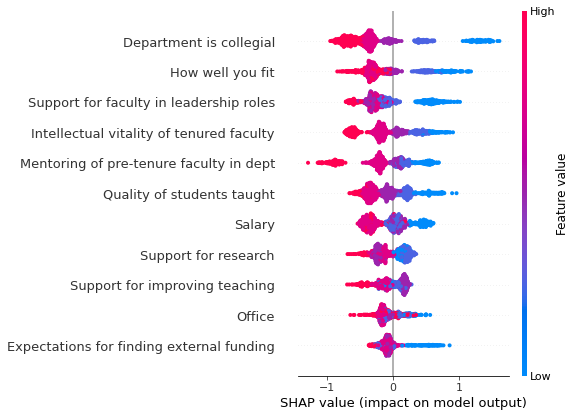

Plotting SHAP beeswarm for class: 1.0


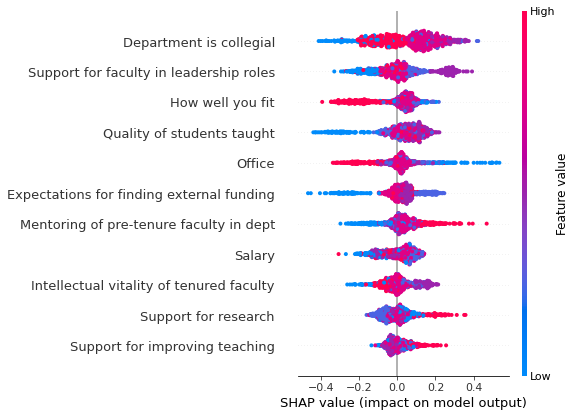

Plotting SHAP beeswarm for class: 2.0


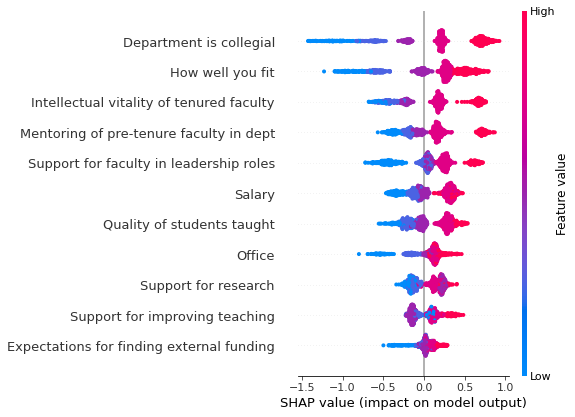

In [108]:
import shap
import matplotlib.pyplot as plt


top_features = features_sorted[:best_feature_count]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

shap_model = CatBoostClassifier(
    auto_class_weights='Balanced', iterations=400,
    learning_rate=0.1, depth=3, random_seed=42, verbose=False
)
shap_model.fit(X_train_top, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_top)

top_feature_descriptions = [name_dict.get(f.lower(), f) for f in top_features]

class_labels = shap_model.classes_

for i, class_name in enumerate(shap_model.classes_):
    print(f"Plotting SHAP beeswarm for class: {class_name}")
    shap.summary_plot(
        shap_values[i],
        features=X_test_top,
        feature_names=top_feature_descriptions,
        plot_type="dot",  # beeswarm
        show=True
    )

In [110]:
X_for_Causal = X_imputed_df[top_features]

_______PC_______


Depth=8, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 75.04it/s]


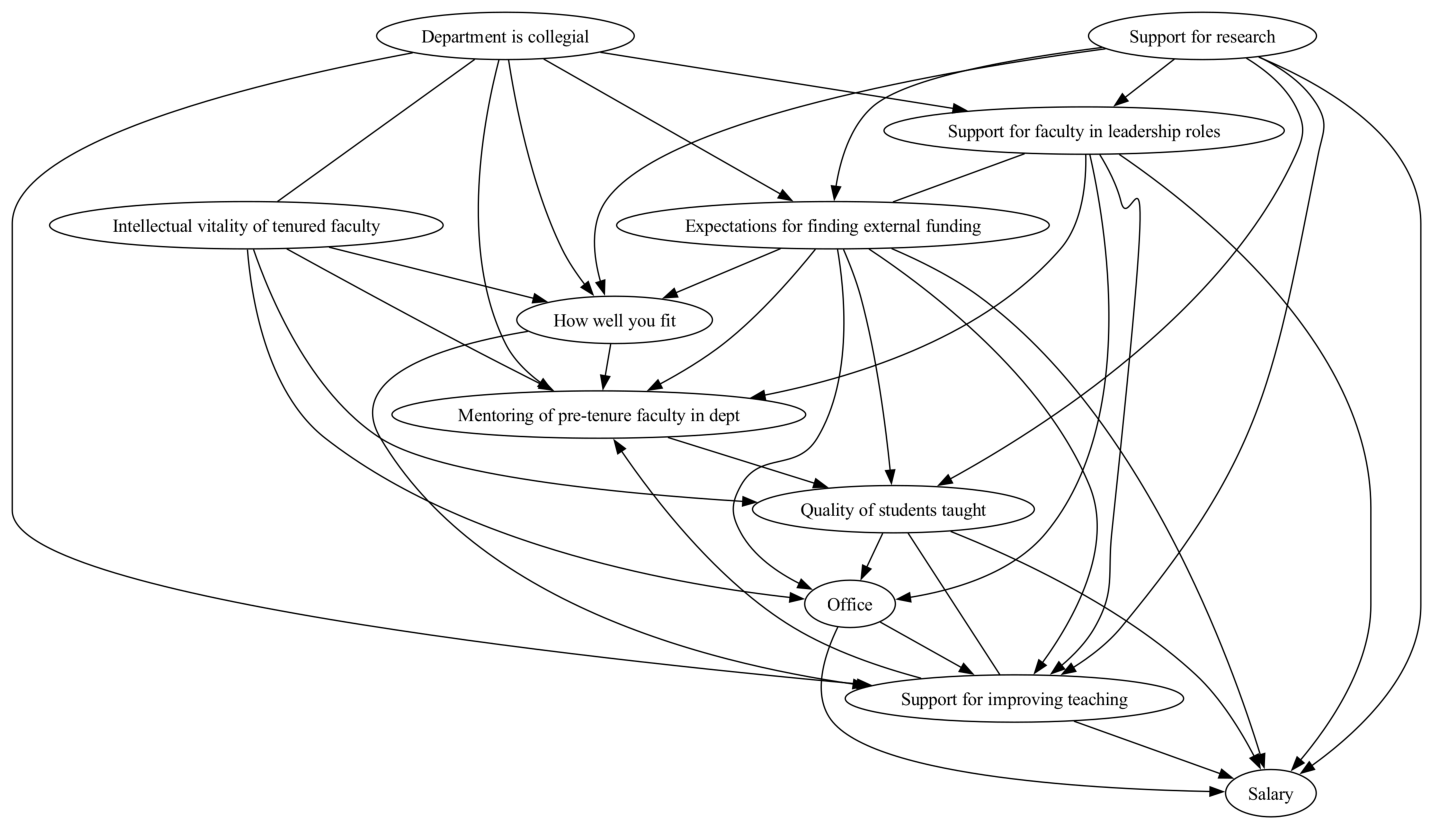

In [111]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
import matplotlib.pyplot as plt
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display
import pandas as pd


X_np = X_for_Causal.to_numpy()  


mapping_df = pd.read_excel("Variables.xlsx")
mapping_df['key'] = mapping_df['key'].str.lower()
name_dict = dict(zip(mapping_df['key'], mapping_df['name']))


original_colnames = [col.lower() for col in X_for_Causal.columns]
node_labels = [name_dict.get(col, col) for col in original_colnames]


print("_______PC_______")
cg_pc = pc(X_np, alpha=0.05, ci_test=fisherz, node_names=node_labels)
cg_pc.draw_pydot_graph()


#print("_______FCI_______")
#cg_fci, sep_set = fci(X_np, alpha=0.05, ci_test="chisq", node_names=node_labels)

# Save FCI graph as PNG
#pdy = GraphUtils.to_pydot(cg_fci)
#pdy.write_png("fci_graph.png")

